In [2]:
import pandas as pd
import numpy as np

In [3]:
df = pd.read_csv("../data/processed/epl_clean.csv")

In [4]:
df["MatchDate"] = pd.to_datetime(df["MatchDate"])

df = df.sort_values("MatchDate").reset_index(drop=True)

In [5]:
home_df = pd.DataFrame({
    "MatchDate": df["MatchDate"],
    "Season": df["Season"],
    "Team": df["HomeTeam"],
    "Opponent": df["AwayTeam"],
    "Venue": "Home",
    "GoalsScored": df["FullTimeHomeGoals"],
    "GoalsConceded": df["FullTimeAwayGoals"]
})

home_df["Points"] = np.where(
    df["FullTimeResult"] == "H",
    3,
    np.where(df["FullTimeResult"] == "D", 1, 0)
)

In [6]:
away_df = pd.DataFrame({
    "MatchDate": df["MatchDate"],
    "Season": df["Season"],
    "Team": df["AwayTeam"],
    "Opponent": df["HomeTeam"],
    "Venue": "Away",
    "GoalsScored": df["FullTimeAwayGoals"],
    "GoalsConceded": df["FullTimeHomeGoals"]
})

away_df["Points"] = np.where(
    df["FullTimeResult"] == "A",
    3,
    np.where(df["FullTimeResult"] == "D", 1, 0)
)

In [7]:
team_history = pd.concat(
    [home_df, away_df],
    ignore_index=True
)

team_history = team_history.sort_values(
    ["Team", "MatchDate"]
).reset_index(drop=True)

In [8]:
team_history.head()

,MatchDate,Season,Team,Opponent,Venue,GoalsScored,GoalsConceded,Points
0,2000-08-19,2000/01,Arsenal,Sunderland,Away,0,1,0
1,2000-08-21,2000/01,Arsenal,Liverpool,Home,2,0,3
2,2000-08-26,2000/01,Arsenal,Charlton,Home,5,3,3
3,2000-09-06,2000/01,Arsenal,Chelsea,Away,2,2,1
4,2000-09-09,2000/01,Arsenal,Bradford,Away,1,1,1


In [9]:
team_history["RecentForm"] = (
    team_history
    .groupby("Team")["Points"]
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).sum()
    )
)

team_history["RecentForm"] = team_history["RecentForm"].fillna(0)

In [10]:
team_history[
    team_history["Team"] == "Liverpool"
][["MatchDate", "Points", "RecentForm"]].head(10)

,MatchDate,Points,RecentForm
8650,2000-08-19,3,0.0
8651,2000-08-21,0,3.0
8652,2000-08-26,1,3.0
8653,2000-09-06,3,4.0
8654,2000-09-09,3,7.0
8655,2000-09-17,1,10.0
8656,2000-09-23,1,8.0
8657,2000-10-01,0,9.0
8658,2000-10-15,3,8.0
8659,2000-10-21,3,8.0


# Merge RecentForm back to original datset

In [11]:
home_form = team_history[
    ["MatchDate", "Team", "RecentForm"]
].rename(
    columns={
        "Team": "HomeTeam",
        "RecentForm": "HomeForm"
    }
)

In [12]:
away_form = team_history[
    ["MatchDate", "Team", "RecentForm"]
].rename(
    columns={
        "Team": "AwayTeam",
        "RecentForm": "AwayForm"
    }
)

In [13]:
df = df.merge(
    home_form,
    on=["MatchDate", "HomeTeam"],
    how="left"
)

In [14]:
df = df.merge(
    away_form,
    on=["MatchDate", "AwayTeam"],
    how="left"
)

In [15]:
df[
    [
        "MatchDate",
        "HomeTeam",
        "AwayTeam",
        "HomeForm",
        "AwayForm"
    ]
].head(20)

,MatchDate,HomeTeam,AwayTeam,HomeForm,AwayForm
0,2000-08-19,Charlton,Man City,0.0,0.0
1,2000-08-19,Chelsea,West Ham,0.0,0.0
2,2000-08-19,Coventry,Middlesbrough,0.0,0.0
3,2000-08-19,Derby,Southampton,0.0,0.0
4,2000-08-19,Leeds,Everton,0.0,0.0
5,2000-08-19,Leicester,Aston Villa,0.0,0.0
6,2000-08-19,Liverpool,Bradford,0.0,0.0
7,2000-08-19,Sunderland,Arsenal,0.0,0.0
8,2000-08-19,Tottenham,Ipswich,0.0,0.0
9,2000-08-20,Man United,Newcastle,0.0,0.0


In [16]:
df[df["HomeTeam"] == "Liverpool"][
    [
        "MatchDate",
        "HomeTeam",
        "HomeForm"
    ]
].head(10)

,MatchDate,HomeTeam,HomeForm
6,2000-08-19,Liverpool,0.0
34,2000-09-06,Liverpool,4.0
43,2000-09-09,Liverpool,7.0
67,2000-09-23,Liverpool,8.0
95,2000-10-21,Liverpool,8.0
107,2000-10-29,Liverpool,8.0
128,2000-11-12,Liverpool,9.0
151,2000-12-02,Liverpool,6.0
168,2000-12-10,Liverpool,6.0
183,2000-12-23,Liverpool,6.0


In [17]:
df.to_csv(
    "../data/processed/epl_features_step1.csv",
    index=False
)

# Rolling Goals Scored

In [18]:
team_history["GoalsScoredAvg5"] = (
    team_history
    .groupby("Team")["GoalsScored"]
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

In [19]:
team_history["GoalsScoredAvg5"] = (
    team_history["GoalsScoredAvg5"]
    .fillna(0)
)

In [20]:
team_history[
    team_history["Team"]=="Liverpool"
][
    [
        "MatchDate",
        "GoalsScored",
        "GoalsScoredAvg5"
    ]
].head(10)

,MatchDate,GoalsScored,GoalsScoredAvg5
8650,2000-08-19,1,0.000000
8651,2000-08-21,0,1.000000
8652,2000-08-26,3,0.500000
8653,2000-09-06,3,1.333333
8654,2000-09-09,3,1.750000
8655,2000-09-17,1,2.000000
8656,2000-09-23,1,2.000000
8657,2000-10-01,0,2.200000
8658,2000-10-15,4,1.600000
8659,2000-10-21,1,1.800000


In [21]:
home_goals = team_history[
    ["MatchDate","Team","GoalsScoredAvg5"]
].rename(
    columns={
        "Team":"HomeTeam",
        "GoalsScoredAvg5":"HomeGoalsAvg5"
    }
)

In [22]:
away_goals = team_history[
    ["MatchDate","Team","GoalsScoredAvg5"]
].rename(
    columns={
        "Team":"AwayTeam",
        "GoalsScoredAvg5":"AwayGoalsAvg5"
    }
)

In [23]:
df = df.merge(
    home_goals,
    on=["MatchDate","HomeTeam"],
    how="left"
)

In [24]:
df = df.merge(
    away_goals,
    on=["MatchDate","AwayTeam"],
    how="left"
)

In [25]:
df[
    [
        "HomeTeam",
        "AwayTeam",
        "HomeGoalsAvg5",
        "AwayGoalsAvg5"
    ]
].head()

,HomeTeam,AwayTeam,HomeGoalsAvg5,AwayGoalsAvg5
0,Charlton,Man City,0.0,0.0
1,Chelsea,West Ham,0.0,0.0
2,Coventry,Middlesbrough,0.0,0.0
3,Derby,Southampton,0.0,0.0
4,Leeds,Everton,0.0,0.0


In [26]:
df[
    df["HomeTeam"] == "Liverpool"
][[
    "MatchDate",
    "HomeTeam",
    "HomeGoalsAvg5"
]].head(10)

,MatchDate,HomeTeam,HomeGoalsAvg5
6,2000-08-19,Liverpool,0.000000
34,2000-09-06,Liverpool,1.333333
43,2000-09-09,Liverpool,1.750000
67,2000-09-23,Liverpool,2.000000
95,2000-10-21,Liverpool,1.800000
107,2000-10-29,Liverpool,1.400000
128,2000-11-12,Liverpool,2.200000
151,2000-12-02,Liverpool,2.400000
168,2000-12-10,Liverpool,2.400000
183,2000-12-23,Liverpool,1.200000


In [27]:
df.to_csv(
    "../data/processed/epl_features_step2.csv",
    index=False
)

# HomeGoalsConcededAvg5
# AwayGoalsConcededAvg5

In [28]:
team_history["GoalsConcededAvg5"] = (
    team_history
    .groupby("Team")["GoalsConceded"]
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

In [29]:
team_history["GoalsConcededAvg5"] = (
    team_history["GoalsConcededAvg5"]
    .fillna(0)
)

In [30]:
home_conceded = team_history[
    ["MatchDate","Team","GoalsConcededAvg5"]
].rename(
    columns={
        "Team":"HomeTeam",
        "GoalsConcededAvg5":"HomeGoalsConcededAvg5"
    }
)

In [31]:
away_conceded = team_history[
    ["MatchDate","Team","GoalsConcededAvg5"]
].rename(
    columns={
        "Team":"AwayTeam",
        "GoalsConcededAvg5":"AwayGoalsConcededAvg5"
    }
)

In [32]:
df = df.merge(
    home_conceded,
    on=["MatchDate","HomeTeam"],
    how="left"
)

df = df.merge(
    away_conceded,
    on=["MatchDate","AwayTeam"],
    how="left"
)

In [33]:
df[
    [
        "HomeTeam",
        "AwayTeam",
        "HomeGoalsConcededAvg5",
        "AwayGoalsConcededAvg5"
    ]
].head()

,HomeTeam,AwayTeam,HomeGoalsConcededAvg5,AwayGoalsConcededAvg5
0,Charlton,Man City,0.0,0.0
1,Chelsea,West Ham,0.0,0.0
2,Coventry,Middlesbrough,0.0,0.0
3,Derby,Southampton,0.0,0.0
4,Leeds,Everton,0.0,0.0


# Home Strength & Away Strength


In [34]:
team_history["HomeWin"] = np.where(
    (team_history["Venue"] == "Home") &
    (team_history["Points"] == 3),
    1,
    0
)

In [35]:
team_history["HomeWinRate5"] = (
    team_history[team_history["Venue"] == "Home"]
    .groupby("Team")["HomeWin"]
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

In [36]:
team_history["AwayWin"] = np.where(
    (team_history["Venue"] == "Away") &
    (team_history["Points"] == 3),
    1,
    0
)

In [37]:
team_history["AwayWinRate5"] = (
    team_history[team_history["Venue"] == "Away"]
    .groupby("Team")["AwayWin"]
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).mean()
    )
)

In [38]:
team_history["HomeWinRate5"] = team_history["HomeWinRate5"].fillna(0)
team_history["AwayWinRate5"] = team_history["AwayWinRate5"].fillna(0)

In [39]:
home_strength = team_history[
    ["MatchDate", "Team", "HomeWinRate5"]
].rename(
    columns={
        "Team": "HomeTeam",
        "HomeWinRate5": "HomeWinRate5"
    }
)

df = df.merge(
    home_strength,
    on=["MatchDate", "HomeTeam"],
    how="left"
)

In [40]:
away_strength = team_history[
    ["MatchDate", "Team", "AwayWinRate5"]
].rename(
    columns={
        "Team": "AwayTeam",
        "AwayWinRate5": "AwayWinRate5"
    }
)

df = df.merge(
    away_strength,
    on=["MatchDate", "AwayTeam"],
    how="left"
)

In [41]:
df[
    [
        "HomeTeam",
        "AwayTeam",
        "HomeWinRate5",
        "AwayWinRate5"
    ]
].head(10)

,HomeTeam,AwayTeam,HomeWinRate5,AwayWinRate5
0,Charlton,Man City,0.0,0.0
1,Chelsea,West Ham,0.0,0.0
2,Coventry,Middlesbrough,0.0,0.0
3,Derby,Southampton,0.0,0.0
4,Leeds,Everton,0.0,0.0
5,Leicester,Aston Villa,0.0,0.0
6,Liverpool,Bradford,0.0,0.0
7,Sunderland,Arsenal,0.0,0.0
8,Tottenham,Ipswich,0.0,0.0
9,Man United,Newcastle,0.0,0.0


# Head-to-Head Feature


In [42]:
df["H2HHomePoints"] = np.where(
    df["FullTimeResult"] == "H",
    3,
    np.where(df["FullTimeResult"] == "D", 1, 0)
)

In [43]:
df["TeamPair"] = df.apply(
    lambda row: "_".join(
        sorted([row["HomeTeam"], row["AwayTeam"]])
    ),
    axis=1
)

In [44]:
df = df.sort_values("MatchDate").reset_index(drop=True)

In [45]:
df["H2HForm5"] = (
    df.groupby("TeamPair")["H2HHomePoints"]
      .transform(
          lambda x: x.shift(1).rolling(5, min_periods=1).sum()
      )
)

In [47]:
df["H2HForm5"] = df["H2HForm5"].fillna(0)

In [48]:
df[
    (
        (df["HomeTeam"] == "Liverpool") &
        (df["AwayTeam"] == "Chelsea")
    ) |
    (
        (df["HomeTeam"] == "Chelsea") &
        (df["AwayTeam"] == "Liverpool")
    )
][
    [
        "MatchDate",
        "HomeTeam",
        "AwayTeam",
        "FullTimeResult",
        "H2HForm5"
    ]
].head(15)

,MatchDate,HomeTeam,AwayTeam,FullTimeResult,H2HForm5
77,2000-10-01,Chelsea,Liverpool,H,0.0
366,2001-05-08,Liverpool,Chelsea,D,3.0
544,2001-12-16,Chelsea,Liverpool,H,4.0
688,2002-03-24,Liverpool,Chelsea,H,7.0
846,2002-10-06,Liverpool,Chelsea,H,10.0
1134,2003-05-11,Chelsea,Liverpool,H,13.0
1149,2003-08-17,Liverpool,Chelsea,A,13.0
1331,2004-01-07,Chelsea,Liverpool,A,12.0
1551,2004-10-03,Chelsea,Liverpool,H,9.0
1677,2005-01-01,Liverpool,Chelsea,A,9.0


In [49]:
def get_h2h_points(row):
    if row["FullTimeResult"] == "D":
        return 1

    if row["FullTimeResult"] == "H":
        return 3

    return 0

In [50]:
team_history["H2HKey"] = (
    team_history["Team"] + "_" +
    team_history["Opponent"]
)

In [51]:
team_history["H2HForm5"] = (
    team_history
    .groupby("H2HKey")["Points"]
    .transform(
        lambda x: x.shift(1).rolling(5, min_periods=1).sum()
    )
)

In [52]:
team_history["H2HForm5"] = (
    team_history["H2HForm5"].fillna(0)
)

In [53]:
home_h2h = team_history[
    ["MatchDate", "Team", "Opponent", "H2HForm5"]
].rename(
    columns={
        "Team": "HomeTeam",
        "Opponent": "AwayTeam",
        "H2HForm5": "HomeH2HForm5"
    }
)

In [54]:
df = df.merge(
    home_h2h,
    on=["MatchDate", "HomeTeam", "AwayTeam"],
    how="left"
)

In [55]:
df[
    [
        "MatchDate",
        "HomeTeam",
        "AwayTeam",
        "HomeH2HForm5"
    ]
].head(20)

,MatchDate,HomeTeam,AwayTeam,HomeH2HForm5
0,2000-08-19,Charlton,Man City,0.0
1,2000-08-19,Chelsea,West Ham,0.0
2,2000-08-19,Coventry,Middlesbrough,0.0
3,2000-08-19,Derby,Southampton,0.0
4,2000-08-19,Leeds,Everton,0.0
5,2000-08-19,Leicester,Aston Villa,0.0
6,2000-08-19,Liverpool,Bradford,0.0
7,2000-08-19,Sunderland,Arsenal,0.0
8,2000-08-19,Tottenham,Ipswich,0.0
9,2000-08-20,Man United,Newcastle,0.0


In [56]:
df["HomeH2HForm5"].min(), df["HomeH2HForm5"].max()

(np.float64(0.0), np.float64(15.0))

In [57]:
df.to_csv(
    "../data/processed/epl_features_step3.csv",
    index=False
)

# 5.7 — League Position Before the Match


In [58]:
df = pd.read_csv(
    "../data/processed/epl_features_step3.csv"
)

df["MatchDate"] = pd.to_datetime(df["MatchDate"])

df = df.sort_values(
    ["Season", "MatchDate"]
).reset_index(drop=True)

In [59]:
df[["Season", "MatchDate", "HomeTeam", "AwayTeam"]].head()

,Season,MatchDate,HomeTeam,AwayTeam
0,2000/01,2000-08-19,Charlton,Man City
1,2000/01,2000-08-19,Chelsea,West Ham
2,2000/01,2000-08-19,Coventry,Middlesbrough
3,2000/01,2000-08-19,Derby,Southampton
4,2000/01,2000-08-19,Leeds,Everton


In [60]:
def add_league_positions(df):
    df = df.copy()

    home_positions = []
    away_positions = []

    for season, season_df in df.groupby("Season", sort=False):

        teams = set(season_df["HomeTeam"]) | set(season_df["AwayTeam"])

        table = {
            team: {
                "Points": 0,
                "GF": 0,
                "GA": 0
            }
            for team in teams
        }

        for date, day_df in season_df.groupby("MatchDate", sort=True):

            # ---------------------------------
            # 1. Calculate table BEFORE today's matches
            # ---------------------------------

            ranking = sorted(
                teams,
                key=lambda team: (
                    table[team]["Points"],
                    table[team]["GF"] - table[team]["GA"],
                    table[team]["GF"]
                ),
                reverse=True
            )

            position = {
                team: i + 1
                for i, team in enumerate(ranking)
            }

            # ---------------------------------
            # 2. Assign today's pre-match positions
            # ---------------------------------

            for _, match in day_df.iterrows():

                home_positions.append(
                    (match.name, position[match["HomeTeam"]])
                )

                away_positions.append(
                    (match.name, position[match["AwayTeam"]])
                )

            # ---------------------------------
            # 3. NOW update the table
            # ---------------------------------

            for _, match in day_df.iterrows():

                home = match["HomeTeam"]
                away = match["AwayTeam"]

                home_goals = match["FullTimeHomeGoals"]
                away_goals = match["FullTimeAwayGoals"]

                table[home]["GF"] += home_goals
                table[home]["GA"] += away_goals

                table[away]["GF"] += away_goals
                table[away]["GA"] += home_goals

                if home_goals > away_goals:

                    table[home]["Points"] += 3

                elif home_goals < away_goals:

                    table[away]["Points"] += 3

                else:

                    table[home]["Points"] += 1
                    table[away]["Points"] += 1

    # ---------------------------------
    # 4. Put positions back into df
    # ---------------------------------

    home_positions_dict = dict(home_positions)
    away_positions_dict = dict(away_positions)

    df["HomePosition"] = df.index.map(home_positions_dict)
    df["AwayPosition"] = df.index.map(away_positions_dict)

    return df

In [61]:
df = add_league_positions(df)

In [62]:
df[
    [
        "Season",
        "MatchDate",
        "HomeTeam",
        "AwayTeam",
        "HomePosition",
        "AwayPosition"
    ]
].head(20)

,Season,MatchDate,HomeTeam,AwayTeam,HomePosition,AwayPosition
0,2000/01,2000-08-19,Charlton,Man City,15,6
1,2000/01,2000-08-19,Chelsea,West Ham,11,2
2,2000/01,2000-08-19,Coventry,Middlesbrough,20,8
3,2000/01,2000-08-19,Derby,Southampton,9,19
4,2000/01,2000-08-19,Leeds,Everton,17,16
5,2000/01,2000-08-19,Leicester,Aston Villa,7,12
6,2000/01,2000-08-19,Liverpool,Bradford,5,13
7,2000/01,2000-08-19,Sunderland,Arsenal,14,4
8,2000/01,2000-08-19,Tottenham,Ipswich,10,1
9,2000/01,2000-08-20,Man United,Newcastle,13,12


In [63]:
df[
    df["Season"] == df["Season"].iloc[0]
][[
    "MatchDate",
    "HomeTeam",
    "AwayTeam",
    "HomePosition",
    "AwayPosition"
]].tail(20)

,MatchDate,HomeTeam,AwayTeam,HomePosition,AwayPosition
360,2001-05-05,Arsenal,Leeds,2,4
361,2001-05-05,Sunderland,Charlton,7,8
362,2001-05-05,Liverpool,Newcastle,3,10
363,2001-05-05,Leicester,Tottenham,13,11
364,2001-05-05,West Ham,Southampton,15,12
365,2001-05-07,Ipswich,Man City,5,18
366,2001-05-08,Liverpool,Chelsea,3,6
367,2001-05-13,Leeds,Bradford,5,20
368,2001-05-13,Southampton,Man United,13,1
369,2001-05-15,Newcastle,Arsenal,12,2


In [64]:
df[["HomePosition", "AwayPosition"]].isnull().sum()

HomePosition    0
AwayPosition    0
dtype: int64

In [65]:
df.to_csv(
    "../data/processed/epl_features_step4.csv",
    index=False
)

# 5.8 — Recent Goal Difference

In [66]:
team_history["GoalDifference"] = (
    team_history["GoalsScored"] -
    team_history["GoalsConceded"]
)

In [67]:
team_history[
    [
        "Team",
        "MatchDate",
        "GoalsScored",
        "GoalsConceded",
        "GoalDifference"
    ]
].head()

,Team,MatchDate,GoalsScored,GoalsConceded,GoalDifference
0,Arsenal,2000-08-19,0,1,-1
1,Arsenal,2000-08-21,2,0,2
2,Arsenal,2000-08-26,5,3,2
3,Arsenal,2000-09-06,2,2,0
4,Arsenal,2000-09-09,1,1,0


We have used the shift 1 coz current match is not considered in it.

In [68]:
team_history["GoalDiff5"] = (
    team_history
    .groupby("Team")["GoalDifference"]
    .transform(
        lambda x: x.shift(1)
                  .rolling(5, min_periods=1)
                  .sum()
    )
)

In [69]:
team_history["GoalDiff5"] = (
    team_history["GoalDiff5"].fillna(0)
)

In [70]:
team_history[
    team_history["Team"] == "Liverpool"
][
    [
        "MatchDate",
        "GoalsScored",
        "GoalsConceded",
        "GoalDifference",
        "GoalDiff5"
    ]
].head(10)

,MatchDate,GoalsScored,GoalsConceded,GoalDifference,GoalDiff5
8650,2000-08-19,1,0,1,0.0
8651,2000-08-21,0,2,-2,1.0
8652,2000-08-26,3,3,0,-1.0
8653,2000-09-06,3,1,2,-1.0
8654,2000-09-09,3,2,1,1.0
8655,2000-09-17,1,1,0,2.0
8656,2000-09-23,1,1,0,1.0
8657,2000-10-01,0,3,-3,3.0
8658,2000-10-15,4,0,4,0.0
8659,2000-10-21,1,0,1,2.0


In [71]:
home_goal_diff = team_history[
    ["MatchDate", "Team", "GoalDiff5"]
].rename(
    columns={
        "Team": "HomeTeam",
        "GoalDiff5": "HomeGoalDiff5"
    }
)

In [72]:
away_goal_diff = team_history[
    ["MatchDate", "Team", "GoalDiff5"]
].rename(
    columns={
        "Team": "AwayTeam",
        "GoalDiff5": "AwayGoalDiff5"
    }
)

In [73]:
df = df.merge(
    home_goal_diff,
    on=["MatchDate", "HomeTeam"],
    how="left"
)

df = df.merge(
    away_goal_diff,
    on=["MatchDate", "AwayTeam"],
    how="left"
)

In [77]:
df = df.merge(
    home_goal_diff,
    on=["MatchDate", "HomeTeam"],
    how="left"
)

df = df.merge(
    away_goal_diff,
    on=["MatchDate", "AwayTeam"],
    how="left"
)

In [78]:
df[
    [
        "MatchDate",
        "HomeTeam",
        "AwayTeam",
        "HomeGoalDiff5",
        "AwayGoalDiff5"
    ]
].head(20)

,MatchDate,HomeTeam,AwayTeam,HomeGoalDiff5,AwayGoalDiff5
0,2000-08-19,Charlton,Man City,0.0,0.0
1,2000-08-19,Chelsea,West Ham,0.0,0.0
2,2000-08-19,Coventry,Middlesbrough,0.0,0.0
3,2000-08-19,Derby,Southampton,0.0,0.0
4,2000-08-19,Leeds,Everton,0.0,0.0
5,2000-08-19,Leicester,Aston Villa,0.0,0.0
6,2000-08-19,Liverpool,Bradford,0.0,0.0
7,2000-08-19,Sunderland,Arsenal,0.0,0.0
8,2000-08-19,Tottenham,Ipswich,0.0,0.0
9,2000-08-20,Man United,Newcastle,0.0,0.0


In [79]:
df[
    ["HomeGoalDiff5", "AwayGoalDiff5"]
].isnull().sum()

HomeGoalDiff5    0
AwayGoalDiff5    0
dtype: int64

In [80]:
df.to_csv(
    "../data/processed/epl_features_step5.csv",
    index=False
)

# 5.9 — Rest Days 

In [81]:
team_history = team_history.sort_values(
    ["Team", "MatchDate"]
).reset_index(drop=True)

In [82]:
team_history["PreviousMatchDate"] = (
    team_history
    .groupby("Team")["MatchDate"]
    .shift(1)
)

In [83]:
team_history["RestDays"] = (
    team_history["MatchDate"] -
    team_history["PreviousMatchDate"]
).dt.days

In [84]:
team_history[
    [
        "Team",
        "MatchDate",
        "PreviousMatchDate",
        "RestDays"
    ]
].head(20)

,Team,MatchDate,PreviousMatchDate,RestDays
0,Arsenal,2000-08-19,NaT,NaN
1,Arsenal,2000-08-21,2000-08-19,2.0
2,Arsenal,2000-08-26,2000-08-21,5.0
3,Arsenal,2000-09-06,2000-08-26,11.0
4,Arsenal,2000-09-09,2000-09-06,3.0
5,Arsenal,2000-09-16,2000-09-09,7.0
6,Arsenal,2000-09-23,2000-09-16,7.0
7,Arsenal,2000-10-01,2000-09-23,8.0
8,Arsenal,2000-10-14,2000-10-01,13.0
9,Arsenal,2000-10-21,2000-10-14,7.0


In [85]:
team_history["RestDays"] = (
    team_history["RestDays"].fillna(7)
)

In [86]:
home_rest = team_history[
    ["MatchDate", "Team", "RestDays"]
].rename(
    columns={
        "Team": "HomeTeam",
        "RestDays": "HomeRestDays"
    }
)

In [87]:
away_rest = team_history[
    ["MatchDate", "Team", "RestDays"]
].rename(
    columns={
        "Team": "AwayTeam",
        "RestDays": "AwayRestDays"
    }
)

In [88]:
df = df.merge(
    home_rest,
    on=["MatchDate", "HomeTeam"],
    how="left"
)

df = df.merge(
    away_rest,
    on=["MatchDate", "AwayTeam"],
    how="left"
)

In [89]:
df[
    [
        "MatchDate",
        "HomeTeam",
        "AwayTeam",
        "HomeRestDays",
        "AwayRestDays"
    ]
].head(20)

,MatchDate,HomeTeam,AwayTeam,HomeRestDays,AwayRestDays
0,2000-08-19,Charlton,Man City,7.0,7.0
1,2000-08-19,Chelsea,West Ham,7.0,7.0
2,2000-08-19,Coventry,Middlesbrough,7.0,7.0
3,2000-08-19,Derby,Southampton,7.0,7.0
4,2000-08-19,Leeds,Everton,7.0,7.0
5,2000-08-19,Leicester,Aston Villa,7.0,7.0
6,2000-08-19,Liverpool,Bradford,7.0,7.0
7,2000-08-19,Sunderland,Arsenal,7.0,7.0
8,2000-08-19,Tottenham,Ipswich,7.0,7.0
9,2000-08-20,Man United,Newcastle,7.0,7.0


In [90]:
df[
    ["HomeRestDays", "AwayRestDays"]
].describe()

,HomeRestDays,AwayRestDays
count,9380.000000,9380.000000
mean,13.365885,12.281130
std,114.579157,96.311723
min,2.000000,2.000000
25%,5.000000,5.000000
50%,7.000000,7.000000
75%,8.000000,8.000000
max,8134.000000,5971.000000


In [91]:
df[
    ["HomeRestDays", "AwayRestDays"]
].isnull().sum()

HomeRestDays    0
AwayRestDays    0
dtype: int64

In [92]:
df.to_csv(
    "../data/processed/epl_features_final.csv",
    index=False
)

# Step 6 — Feature Audit

In [93]:
import pandas as pd

df = pd.read_csv(
    "../data/processed/epl_features_final.csv"
)

df["MatchDate"] = pd.to_datetime(df["MatchDate"])

df = df.sort_values("MatchDate").reset_index(drop=True)

In [94]:
df.shape

(9380, 44)

In [95]:
df.columns.tolist()

['Season',
 'MatchDate',
 'HomeTeam',
 'AwayTeam',
 'FullTimeHomeGoals',
 'FullTimeAwayGoals',
 'FullTimeResult',
 'HalfTimeHomeGoals',
 'HalfTimeAwayGoals',
 'HalfTimeResult',
 'HomeShots',
 'AwayShots',
 'HomeShotsOnTarget',
 'AwayShotsOnTarget',
 'HomeCorners',
 'AwayCorners',
 'HomeFouls',
 'AwayFouls',
 'HomeYellowCards',
 'AwayYellowCards',
 'HomeRedCards',
 'AwayRedCards',
 'HomeForm',
 'AwayForm',
 'HomeGoalsAvg5',
 'AwayGoalsAvg5',
 'HomeGoalsConcededAvg5',
 'AwayGoalsConcededAvg5',
 'HomeWinRate5',
 'AwayWinRate5',
 'H2HHomePoints',
 'TeamPair',
 'H2HForm5',
 'HomeH2HForm5',
 'HomePosition',
 'AwayPosition',
 'HomeGoalDiff5_x',
 'AwayGoalDiff5_x',
 'HomeGoalDiff5_y',
 'AwayGoalDiff5_y',
 'HomeGoalDiff5',
 'AwayGoalDiff5',
 'HomeRestDays',
 'AwayRestDays']

In [96]:
df.isnull().sum()

Season                   0
MatchDate                0
HomeTeam                 0
AwayTeam                 0
FullTimeHomeGoals        0
FullTimeAwayGoals        0
FullTimeResult           0
HalfTimeHomeGoals        0
HalfTimeAwayGoals        0
HalfTimeResult           0
HomeShots                0
AwayShots                0
HomeShotsOnTarget        0
AwayShotsOnTarget        0
HomeCorners              0
AwayCorners              0
HomeFouls                0
AwayFouls                0
HomeYellowCards          0
AwayYellowCards          0
HomeRedCards             0
AwayRedCards             0
HomeForm                 0
AwayForm                 0
HomeGoalsAvg5            0
AwayGoalsAvg5            0
HomeGoalsConcededAvg5    0
AwayGoalsConcededAvg5    0
HomeWinRate5             0
AwayWinRate5             0
H2HHomePoints            0
TeamPair                 0
H2HForm5                 0
HomeH2HForm5             0
HomePosition             0
AwayPosition             0
HomeGoalDiff5_x          0
A

In [97]:
df.duplicated().sum()

np.int64(0)

In [98]:
df["FullTimeResult"].value_counts()

FullTimeResult
H    4299
A    2768
D    2313
Name: count, dtype: int64

In [99]:
df["FullTimeResult"].value_counts(normalize=True) * 100

FullTimeResult
H    45.831557
A    29.509595
D    24.658849
Name: proportion, dtype: float64

In [102]:
feature_cols = [
    "HomeForm",
    "AwayForm",
    "HomeGoalsAvg5",
    "AwayGoalsAvg5",
    "HomeGoalsConcededAvg5",
    "AwayGoalsConcededAvg5",
    "HomeWinRate5",
    "AwayWinRate5",
    "HomeH2HForm5",
    "HomePosition",
    "AwayPosition",
    "HomeGoalDiff5",
    "AwayGoalDiff5",
    "HomeRestDays",
    "AwayRestDays"
]

In [103]:
df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
HomeForm,9380.0,6.734861,3.444991,0.0,4.0,7.0,9.0,15.0
AwayForm,9380.0,6.968124,3.422477,0.0,4.0,7.0,9.0,15.0
HomeGoalsAvg5,9380.0,1.340219,0.652204,0.0,0.8,1.2,1.8,5.8
AwayGoalsAvg5,9380.0,1.372367,0.657919,0.0,1.0,1.2,1.8,4.8
HomeGoalsConcededAvg5,9380.0,1.370421,0.620049,0.0,1.0,1.4,1.8,5.0
AwayGoalsConcededAvg5,9380.0,1.333534,0.610928,0.0,1.0,1.2,1.8,4.6
HomeWinRate5,9380.0,0.458479,0.259201,0.0,0.2,0.4,0.6,1.0
AwayWinRate5,9380.0,0.294296,0.241008,0.0,0.2,0.2,0.4,1.0
HomeH2HForm5,9380.0,5.202985,3.988916,0.0,2.0,5.0,8.0,15.0
HomePosition,9380.0,10.821109,5.737569,1.0,6.0,11.0,16.0,20.0


In [104]:
leakage_cols = [
    "FullTimeHomeGoals",
    "FullTimeAwayGoals",
    "FullTimeResult",
    "HalfTimeHomeGoals",
    "HalfTimeAwayGoals",
    "HalfTimeResult",
    "HomeShots",
    "AwayShots",
    "HomeShotsOnTarget",
    "AwayShotsOnTarget",
    "HomeCorners",
    "AwayCorners",
    "HomeFouls",
    "AwayFouls",
    "HomeYellowCards",
    "AwayYellowCards",
    "HomeRedCards",
    "AwayRedCards"
]

In [105]:
X = df[feature_cols]
y = df["FullTimeResult"]

In [106]:
df.shape

(9380, 44)

In [107]:
df[feature_cols].isnull().sum()

HomeForm                 0
AwayForm                 0
HomeGoalsAvg5            0
AwayGoalsAvg5            0
HomeGoalsConcededAvg5    0
AwayGoalsConcededAvg5    0
HomeWinRate5             0
AwayWinRate5             0
HomeH2HForm5             0
HomePosition             0
AwayPosition             0
HomeGoalDiff5            0
AwayGoalDiff5            0
HomeRestDays             0
AwayRestDays             0
dtype: int64

In [108]:
df.duplicated().sum()

np.int64(0)

In [109]:
df["FullTimeResult"].value_counts(normalize=True) * 100

FullTimeResult
H    45.831557
A    29.509595
D    24.658849
Name: proportion, dtype: float64

## 6.1 — Check Feature Statistics

In [113]:
df[feature_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
HomeForm,9380.0,6.734861,3.444991,0.0,4.0,7.0,9.0,15.0
AwayForm,9380.0,6.968124,3.422477,0.0,4.0,7.0,9.0,15.0
HomeGoalsAvg5,9380.0,1.340219,0.652204,0.0,0.8,1.2,1.8,5.8
AwayGoalsAvg5,9380.0,1.372367,0.657919,0.0,1.0,1.2,1.8,4.8
HomeGoalsConcededAvg5,9380.0,1.370421,0.620049,0.0,1.0,1.4,1.8,5.0
AwayGoalsConcededAvg5,9380.0,1.333534,0.610928,0.0,1.0,1.2,1.8,4.6
HomeWinRate5,9380.0,0.458479,0.259201,0.0,0.2,0.4,0.6,1.0
AwayWinRate5,9380.0,0.294296,0.241008,0.0,0.2,0.2,0.4,1.0
HomeH2HForm5,9380.0,5.202985,3.988916,0.0,2.0,5.0,8.0,15.0
HomePosition,9380.0,10.821109,5.737569,1.0,6.0,11.0,16.0,20.0


In [114]:
df[
    [
        "HomeWinRate5",
        "AwayWinRate5",
        "HomePosition",
        "AwayPosition",
        "HomeRestDays",
        "AwayRestDays"
    ]
].describe()

,HomeWinRate5,AwayWinRate5,HomePosition,AwayPosition,HomeRestDays,AwayRestDays
count,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000,9380.000000
mean,0.458479,0.294296,10.821109,10.607356,13.365885,12.281130
std,0.259201,0.241008,5.737569,5.692487,114.579157,96.311723
min,0.000000,0.000000,1.000000,1.000000,2.000000,2.000000
25%,0.200000,0.200000,6.000000,6.000000,5.000000,5.000000
50%,0.400000,0.200000,11.000000,11.000000,7.000000,7.000000
75%,0.600000,0.400000,16.000000,15.000000,8.000000,8.000000
max,1.000000,1.000000,20.000000,20.000000,8134.000000,5971.000000


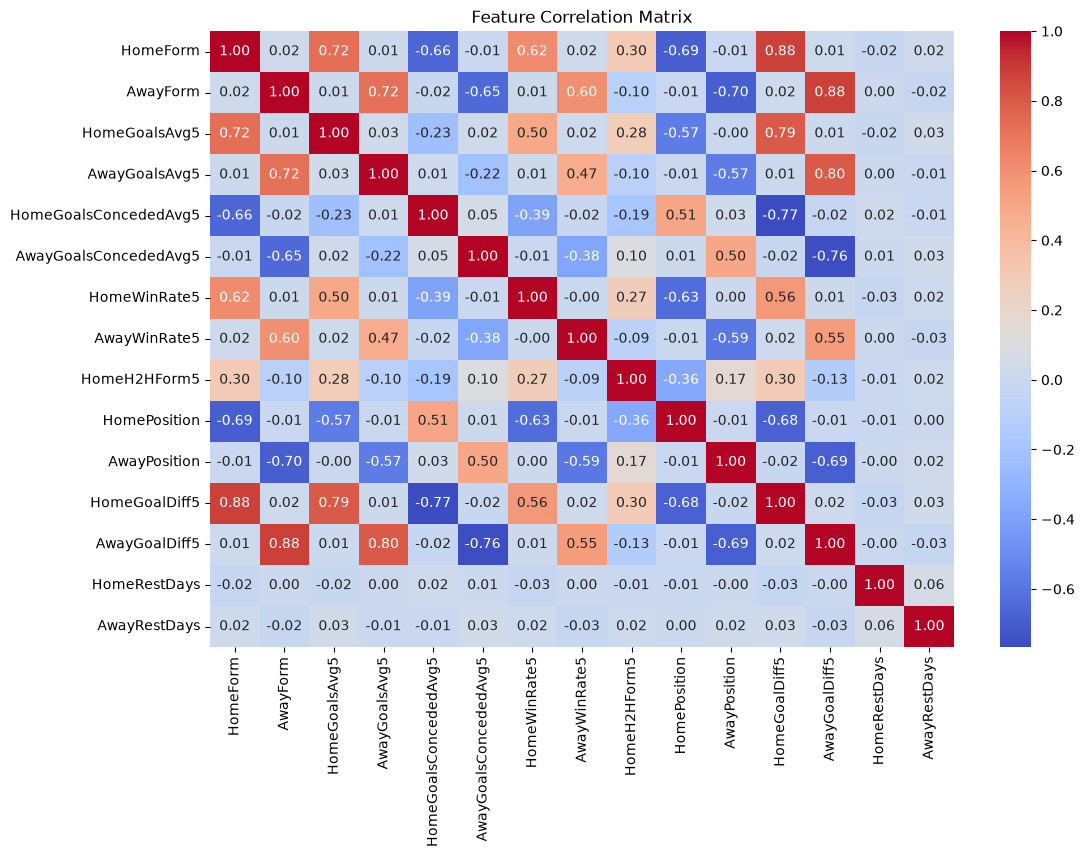

In [120]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))

sns.heatmap(
    df[feature_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Feature Correlation Matrix")
plt.show()

In [121]:
df[["MatchDate", "Season"]].head(10)

,MatchDate,Season
0,2000-08-19,2000/01
1,2000-08-19,2000/01
2,2000-08-19,2000/01
3,2000-08-19,2000/01
4,2000-08-19,2000/01
5,2000-08-19,2000/01
6,2000-08-19,2000/01
7,2000-08-19,2000/01
8,2000-08-19,2000/01
9,2000-08-20,2000/01


In [122]:
df[["MatchDate", "Season"]].tail(10)

,MatchDate,Season
9370,2025-05-02,2024/25
9371,2025-05-03,2024/25
9372,2025-05-03,2024/25
9373,2025-05-03,2024/25
9374,2025-05-03,2024/25
9375,2025-05-04,2024/25
9376,2025-05-04,2024/25
9377,2025-05-04,2024/25
9378,2025-05-04,2024/25
9379,2025-05-05,2024/25


# Step 7 — Chronological Train/Test Split

In [123]:
df = df.sort_values("MatchDate").reset_index(drop=True)

In [124]:
df[["MatchDate", "Season"]].head()

,MatchDate,Season
0,2000-08-19,2000/01
1,2000-08-19,2000/01
2,2000-08-19,2000/01
3,2000-08-19,2000/01
4,2000-08-19,2000/01


In [125]:
df[["MatchDate", "Season"]].tail()

,MatchDate,Season
9375,2025-05-04,2024/25
9376,2025-05-04,2024/25
9377,2025-05-04,2024/25
9378,2025-05-04,2024/25
9379,2025-05-05,2024/25


Data chronological order mai hai no problem

In [126]:
split_index = int(len(df) * 0.80)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

In [127]:
print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training rows: 7504
Testing rows: 1876


In [128]:
print(
    "Training period:",
    train_df["MatchDate"].min(),
    "to",
    train_df["MatchDate"].max()
)

print(
    "Testing period:",
    test_df["MatchDate"].min(),
    "to",
    test_df["MatchDate"].max()
)

Training period: 2000-08-19 00:00:00 to 2020-07-26 00:00:00
Testing period: 2020-07-26 00:00:00 to 2025-05-05 00:00:00


In [129]:
feature_cols = [
    "HomeForm",
    "AwayForm",
    "HomeGoalsAvg5",
    "AwayGoalsAvg5",
    "HomeGoalsConcededAvg5",
    "AwayGoalsConcededAvg5",
    "HomeWinRate5",
    "AwayWinRate5",
    "HomeH2HForm5",
    "HomePosition",
    "AwayPosition",
    "HomeGoalDiff5",
    "AwayGoalDiff5",
    "HomeRestDays",
    "AwayRestDays"
]

In [130]:
X_train = train_df[feature_cols]
y_train = train_df["FullTimeResult"]

In [131]:
X_test = test_df[feature_cols]
y_test = test_df["FullTimeResult"]

In [134]:
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

X_train: (7504, 15)
y_train: (7504,)
X_test: (1876, 15)
y_test: (1876,)


In [135]:
assert train_df["MatchDate"].max() < test_df["MatchDate"].min()

AssertionError: 

In [136]:
unique_dates = df["MatchDate"].sort_values().unique()

split_date = unique_dates[int(len(unique_dates) * 0.80)]

split_date

Timestamp('2021-02-17 00:00:00')

In [137]:
train_df = df[
    df["MatchDate"] < split_date
].copy()

test_df = df[
    df["MatchDate"] >= split_date
].copy()

In [138]:
print(
    "Training period:",
    train_df["MatchDate"].min(),
    "to",
    train_df["MatchDate"].max()
)

print(
    "Testing period:",
    test_df["MatchDate"].min(),
    "to",
    test_df["MatchDate"].max()
)

Training period: 2000-08-19 00:00:00 to 2021-02-15 00:00:00
Testing period: 2021-02-17 00:00:00 to 2025-05-05 00:00:00


In [139]:
print("Training rows:", len(train_df))
print("Testing rows:", len(test_df))

Training rows: 7745
Testing rows: 1635


In [140]:
assert train_df["MatchDate"].max() < test_df["MatchDate"].min()

In [141]:
set(train_df["MatchDate"]).intersection(
    set(test_df["MatchDate"])
)

set()

In [142]:
X_train = train_df[feature_cols]
y_train = train_df["FullTimeResult"]

X_test = test_df[feature_cols]
y_test = test_df["FullTimeResult"]

In [143]:
print(X_train.shape)
print(X_test.shape)

(7745, 15)
(1635, 15)


In [144]:
train_df.to_csv(
    "../data/processed/train.csv",
    index=False
)

test_df.to_csv(
    "../data/processed/test.csv",
    index=False
)

In [145]:
print("Features used for ML:")
for feature in feature_cols:
    print(feature)

Features used for ML:
HomeForm
AwayForm
HomeGoalsAvg5
AwayGoalsAvg5
HomeGoalsConcededAvg5
AwayGoalsConcededAvg5
HomeWinRate5
AwayWinRate5
HomeH2HForm5
HomePosition
AwayPosition
HomeGoalDiff5
AwayGoalDiff5
HomeRestDays
AwayRestDays
